# Chapitre 5 — Choix optimal du consommateur

## Question du chapitre

Parmi tous les paniers accessibles, lequel est retenu par le consommateur ?

## Idée à comprendre d'abord

Le consommateur cherche le **meilleur panier accessible**. Graphiquement, c'est la courbe d'indifférence la plus élevée qu'il peut encore atteindre compte tenu de sa droite de budget.

## 5.1. Problème de maximisation

Le problème s'écrit :

$$
\max_{x_1,x_2} U(x_1,x_2)
$$

On note $(x_1^*,x_2^*)$ la solution optimale, c'est-à-dire le panier qui maximise l'utilité sous la contrainte budgétaire.

sous la contrainte :

$$
p_1x_1+p_2x_2 \leq R
$$

Si les deux biens sont désirables, le consommateur dépense tout son revenu à l'optimum :

$$
p_1x_1+p_2x_2=R
$$

## 5.2. Optimum intérieur

Quand la solution n'est pas sur un bord, la courbe d'indifférence est tangente à la droite de budget. On obtient :

$$
TMS_{1,2}=\frac{p_1}{p_2}
$$

ou encore :

$$
\frac{U_1'}{U_2'}=\frac{p_1}{p_2} \qquad \left(=-\frac{dx_2}{dx_1}\right)
$$

**Lecture économique** : à l'optimum, le taux d'échange souhaité par le consommateur coïncide avec le taux d'échange imposé par le marché des biens, c'est-à-dire le rapport des prix $p_1/p_2$. Le revenu $R$ détermine jusqu'où s'étend la droite de budget, mais pas sa pente ; deux consommateurs avec des revenus différents font face au même taux d'échange marchand si les prix sont identiques.

## 5.3. Optimum en coin

L'optimum peut se trouver sur un bord si le consommateur achète un seul bien. C'est fréquent avec les substituts parfaits ou, plus généralement, quand la tangence ne fournit pas de solution admissible.

## 5.4. Méthode par Lagrangien

On peut écrire :

$$
\mathcal{L}=U(x_1,x_2)+\lambda(R-p_1x_1-p_2x_2)
$$

Les conditions du premier ordre sont :

$$
\frac{\partial U}{\partial x_1}=\lambda p_1
$$

$$
\frac{\partial U}{\partial x_2}=\lambda p_2
$$

$$
p_1x_1+p_2x_2=R
$$

En divisant les deux premières équations, on retrouve la condition de tangence.

## 5.5. Exemple à savoir refaire : Cobb-Douglas

Si :

$$
U(x_1,x_2)=x_1^a x_2^b
$$

alors :

$$
TMS=\frac{a}{b}\frac{x_2}{x_1}
$$

Avec la contrainte budgétaire, on obtient :

$$
x_1^*=\frac{a}{a+b}\frac{R}{p_1}
$$

$$
x_2^*=\frac{b}{a+b}\frac{R}{p_2}
$$

**À retenir** : dans Cobb-Douglas, une part constante du revenu est affectée à chaque bien.

## Méthode rapide en exercice

1. Écrire la contrainte budgétaire.
2. Calculer le TMS.
3. Poser l'égalité $TMS=p_1/p_2$ si l'optimum est intérieur.
4. Utiliser la contrainte pour obtenir les quantités.
5. Vérifier qu'on n'est pas en coin.

## Erreur classique

Prendre la tangence comme une recette universelle. Elle vaut pour un **optimum intérieur** ; elle ne suffit pas quand les préférences sont particulières ou quand la solution est en coin.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("microeco_v5_figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 200,
    "font.size": 11
})

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.savefig(FIG_DIR / f"{name}.svg", bbox_inches="tight")
    plt.show()


## Graphique — Optimum du consommateur

**Ce qu'il faut voir.** Le point optimal est le panier atteignable situé sur la courbe d'indifférence la plus élevée. Sur le graphique, c'est le point de tangence entre la droite budgétaire et une courbe d'indifférence.

**Comment le lire vite.** Repère d'abord la droite budgétaire, puis la courbe d'indifférence la plus haute encore accessible, puis le point où elles se touchent sans se couper. C'est là que le consommateur n'a plus intérêt à se déplacer.

**Cas concret simple.** Avec un revenu de 12, un prix du bien 1 égal à 2 et un prix du bien 2 égal à 1, le point retenu est ici $(3,6)$. Il utilise tout le budget sans sortir de l'ensemble atteignable.

**Phrase de copie.** À l'optimum intérieur, le consommateur égalise le taux auquel il accepte de substituer les biens et le taux auquel le marché permet cette substitution.


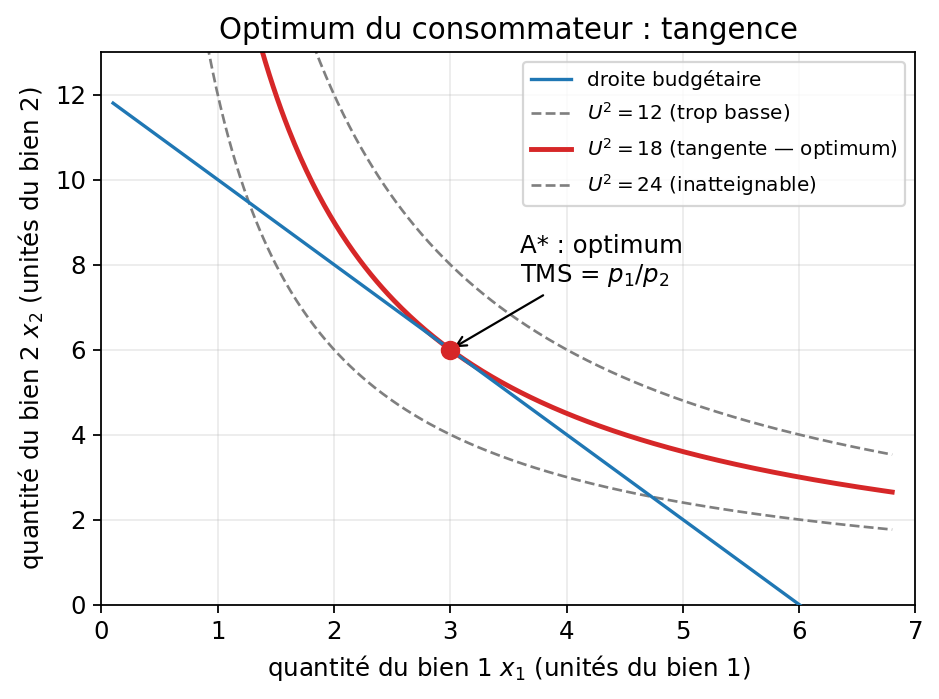

In [ ]:
# 1 budget + indifference + optimum Cobb-Douglas U=sqrt(xy), p1=2,p2=1,R=12 -> 
x = np.linspace(0.1, 6.8, 400); R = 12; p1 = 2; p2 = 1
plt.figure(figsize=(6, 4.5))
plt.plot(x, (R - p1*x)/p2, label='droite budgétaire', color='tab:blue', zorder=3)

# Courbes d'indifférence : U=sqrt(xy) → xy = k → y = k/x
for k, ls, lw, color, lbl in [
    (12, '--', 1.2, 'tab:gray',   r'$U^2=12$ (trop basse)'),
    (18, '-',  2.2, 'tab:red',    r'$U^2=18$ (tangente — optimum)'),
    (24, '--', 1.2, 'tab:gray',   r'$U^2=24$ (inatteignable)'),
]:
    y_ci = k / x
    plt.plot(x[y_ci <= 13.5], y_ci[y_ci <= 13.5],
             linestyle=ls, linewidth=lw, color=color, label=lbl)

plt.scatter([3], [6], zorder=4, color='tab:red', s=60)
plt.annotate('A* : optimum\nTMS = $p_1/p_2$', xy=(3, 6), xytext=(3.6, 7.6),
             arrowprops=dict(arrowstyle='->', color='black'))
plt.xlim(0, 7); plt.ylim(0, 13)
plt.xlabel('quantité du bien 1 $x_1$ (unités du bien 1)')
plt.ylabel('quantité du bien 2 $x_2$ (unités du bien 2)')
plt.title('Optimum du consommateur : tangence')
plt.grid(True, alpha=.25)
plt.legend(loc='upper right', fontsize=9)
save_fig('01_optimum_consommateur')
